In [ ]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os

import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, unpack_sequence
import numpy as np
import yaml
import pandas as pd# 0. Experiment selection
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

In [2]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)
    
# Load models
## Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
## Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()
## Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

Testing experiment: da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr
Device: cuda:1
Loading checkpoint from: ../experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/best_da_model.pth


DomainDiscriminator(
  (gradient_reversal): GradientReversalLayer()
  (discriminator): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [3]:
# Load datasets

# MC
## Create test dataset (using source domain for classification evaluation)
source_config = config['data']['source_domain']
train_events_per_particle = config['data']['source_domain']['events_per_particle']
## Use validation portion of source data for testing (events model hasn't seen)
mc_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nue2_2020': 250_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device=DEVICE,
    shuffle_events=False
)
## Create test dataloader
mc_dataloader = create_numu_dataloader_from_ds(
    dataset=mc_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=False,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {mc_dataloader.batch_size}")
print(f"- Number of batches: {len(mc_dataloader)}")
print(f"- Total events: {len(mc_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

# EXP
## Create a sample of target domain data for domain discrimination test
target_config = config['data']['target_domain']
target_dataset = NuMuDataset(
    h5_path=target_config['h5_path'],
    particle_types=target_config['particle_types'],
    neutrino_types=target_config.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': target_config['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=config['data']['max_hits'],
    device=DEVICE,
    shuffle_events=False
)
target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

print(f"Target Test dataloader created:")
print(f"- Batch size: {target_dataloader.batch_size}")
print(f"- Number of batches: {len(target_dataloader)}")
print(f"- Total events: {len(target_dataset)}")

Test dataloader created:
- Batch size: 256
- Number of batches: 3907
- Total events: 1000000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]
Target Test dataloader created:
- Batch size: 256
- Number of batches: 1368
- Total events: 349976


In [4]:
# Make preds and Collect stats

# MC
mc_raw_data = []
mc_predictions = []
mc_probabilities = []
mc_labels = []
mc_features = []
mc_magic_numbers = []
mc_channels_ids = []
mc_dd_probs = []
with torch.no_grad():
    for batch in tqdm(mc_dataloader, miniters=50, desc='For MC dataset'):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        mc_features.append(feature_repr.cpu())
        mc_predictions.append(predictions_batch.cpu())
        mc_probabilities.append(probabilities_batch.cpu())
        mc_dd_probs.append(dd_probs_batch.cpu())
        mc_labels.append(batch['labels'].cpu())
        mc_magic_numbers.extend(batch['magic_numbers'])
        mc_channels_ids.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        mc_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
## Concatenate all results
mc_features = torch.cat(mc_features, dim=0).numpy()
mc_predictions = torch.cat(mc_predictions, dim=0).numpy().flatten()
mc_probabilities = torch.cat(mc_probabilities, dim=0).numpy().flatten()
mc_labels = torch.cat(mc_labels, dim=0).numpy().flatten()
mc_dd_probs = torch.cat(mc_dd_probs, dim=0).numpy().flatten()


# EXP
exp_raw_data = []
exp_predictions = []
exp_probabilities = []
exp_features = []
exp_channels_ids = []
exp_dd_probs = []
print()
with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50, desc="For EXP (target) dataset"):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_features.append(feature_repr.cpu())
        exp_predictions.append(predictions_batch.cpu())
        exp_probabilities.append(probabilities_batch.cpu())
        exp_dd_probs.append(dd_probs_batch.cpu())
        exp_channels_ids.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        exp_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
## Concatenate all results
exp_features = torch.cat(exp_features, dim=0).numpy()
exp_predictions = torch.cat(exp_predictions, dim=0).numpy().flatten()
exp_probabilities = torch.cat(exp_probabilities, dim=0).numpy().flatten()
exp_dd_probs = torch.cat(exp_dd_probs, dim=0).numpy().flatten()

For MC dataset:   0%|          | 0/3907 [00:00<?, ?it/s]/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
For MC dataset: 100%|██████████| 3907/3907 [01:41<00:00, 38.31it/s]


For EXP (target) dataset: 100%|██████████| 1368/1368 [00:35<00:00, 38.36it/s]


In [5]:
# Collect stats
## MC Truth
mc_signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in mc_magic_numbers])
mc_signal_string_nums = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(mc_magic_numbers, mc_channels_ids)])
## Norms from config
t_mean, t_std = normalization_config['means'][1], normalization_config['stds'][1]
x_mean, x_std = normalization_config['means'][2], normalization_config['stds'][2]
y_mean, y_std = normalization_config['means'][3], normalization_config['stds'][3]
z_mean, z_std = normalization_config['means'][4], normalization_config['stds'][4]
q_mean, q_std = normalization_config['means'][0], normalization_config['stds'][0]
## MC Coordinates
mc_q_means, mc_x_means, mc_y_means, mc_z_means, mc_t_means, mc_z_weight_q, mc_qgt10_num, mc_qgt20_num = \
    np.zeros(len(mc_raw_data)), np.zeros(len(mc_raw_data)), np.zeros(len(mc_raw_data)), \
        np.zeros(len(mc_raw_data)), np.zeros(len(mc_raw_data)), np.zeros(len(mc_raw_data)), \
            np.zeros(len(mc_raw_data)), np.zeros(len(mc_raw_data))
for i, event in enumerate(tqdm(mc_raw_data, desc='MC stats collecting')):
    mc_q_means[i] = (event[:,0]*q_std+q_mean).mean()
    mc_x_means[i] = (event[:,2]*x_std+x_mean).mean()
    mc_y_means[i] = (event[:,3]*y_std+y_mean).mean()
    mc_t_means[i] = (event[:,1]*t_std+t_mean).mean()
    mc_z_means[i] = (event[:,4]*z_std+z_mean).mean()
    mc_z_weight_q[i] = np.sum((event[:,4]*z_std+z_mean)*(event[:,0]*q_std+q_mean))/(event[:,0]*q_std+q_mean).sum()
    mc_qgt10_num[i] = np.sum((event[:,0]*q_std+q_mean)>10)
    mc_qgt20_num[i] = np.sum((event[:,0]*q_std+q_mean)>20)
print(f"Number of MC events with 2 hits > 10 eV: {(mc_qgt10_num>=2).sum()} of {len(mc_qgt10_num)}, {100*(mc_qgt10_num>=2).sum()/len(mc_qgt10_num):.3f}%")
print(f"Number of MC events with weighted_Z<220: {(mc_z_weight_q<220).sum()} of {len(mc_z_weight_q)}, {100*(mc_z_weight_q<220).sum()/len(mc_z_weight_q):.3f}%")
## EXP Coordinates
exp_q_means, exp_x_means, exp_y_means, exp_z_means, exp_t_means, exp_z_weight_q, exp_qgt10_num, exp_qgt20_num = \
    np.zeros(len(exp_raw_data)), np.zeros(len(exp_raw_data)), np.zeros(len(exp_raw_data)), \
        np.zeros(len(exp_raw_data)), np.zeros(len(exp_raw_data)), np.zeros(len(exp_raw_data)), \
            np.zeros(len(exp_raw_data)), np.zeros(len(exp_raw_data))
for i, event in enumerate(tqdm(exp_raw_data, desc='EXP stats collecting')):
    exp_q_means[i] = (event[:,0]*q_std+q_mean).mean()
    exp_x_means[i] = (event[:,2]*x_std+x_mean).mean()
    exp_y_means[i] = (event[:,3]*y_std+y_mean).mean()
    exp_t_means[i] = (event[:,1]*t_std+t_mean).mean()
    exp_z_means[i] = (event[:,4]*z_std+z_mean).mean()
    exp_z_weight_q[i] = np.sum((event[:,4]*z_std+z_mean)*(event[:,0]*q_std+q_mean))/(event[:,0]*q_std+q_mean).sum()
    exp_qgt10_num[i] = np.sum((event[:,0]*q_std+q_mean)>10)
    exp_qgt20_num[i] = np.sum((event[:,0]*q_std+q_mean)>20)
print(f"Number of EXP events with 2 hits > 10 eV: {(exp_qgt10_num>=2).sum()} of {len(exp_qgt10_num)}, {100*(exp_qgt10_num>=2).sum()/len(exp_qgt10_num):.3f}%")
print(f"Number of EXP events with weighted_Z<220: {(exp_z_weight_q<220).sum()} of {len(exp_z_weight_q)}, {100*(exp_z_weight_q<220).sum()/len(exp_z_weight_q):.3f}%")

MC stats collecting: 100%|██████████| 1000000/1000000 [02:02<00:00, 8140.66it/s]


Number of MC events with 2 hits > 10 eV: 220276 of 1000000, 22.028%
Number of MC events with weighted_Z<220: 997141 of 1000000, 99.714%


EXP stats collecting: 100%|██████████| 349976/349976 [00:41<00:00, 8364.00it/s]

Number of EXP events with 2 hits > 10 eV: 55571 of 349976, 15.879%
Number of EXP events with weighted_Z<220: 349948 of 349976, 99.992%


## Plots

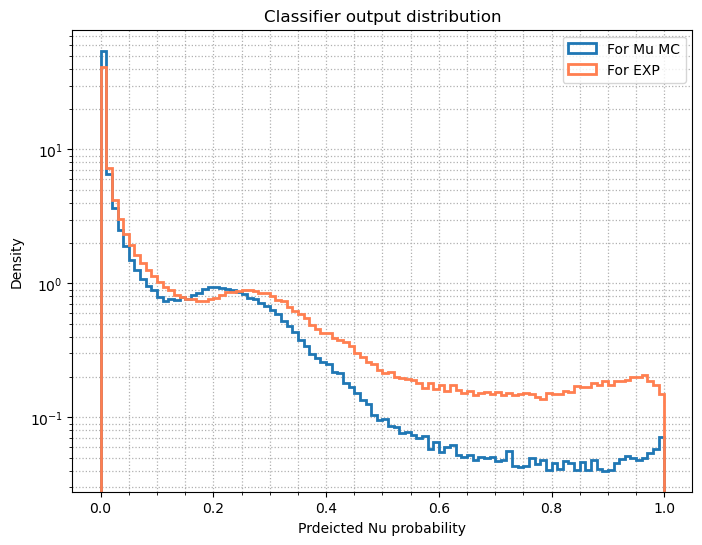

In [6]:
# Pmunu EXP VS MC
mc_mask = np.ones(len(mc_probabilities), dtype=bool) #& (mc_qgt10_num>=2) & (mc_qgt20_num>=1)
labels_masked, mc_probabilities_masked = mc_labels[mc_mask], mc_probabilities[mc_mask]

exp_mask = np.ones(len(exp_probabilities), dtype=bool) #& (exp_qgt10_num>=2) & (exp_qgt20_num>=1)
exp_probas_masked = exp_probabilities[exp_mask]
plt.figure(figsize=(8,6))
plt.hist(mc_probabilities_masked[~labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Mu MC')
plt.hist(exp_probas_masked, color='coral', bins=100, density=True, log=True, histtype='step', lw=2., label='For EXP')
plt.title("Classifier output distribution")
plt.legend()
plt.grid(which='both', ls=':', lw=0.9)
plt.xlabel("Prdeicted Nu probability")
plt.ylabel("Density")
plt.minorticks_on()
plt.show()
plt.close()

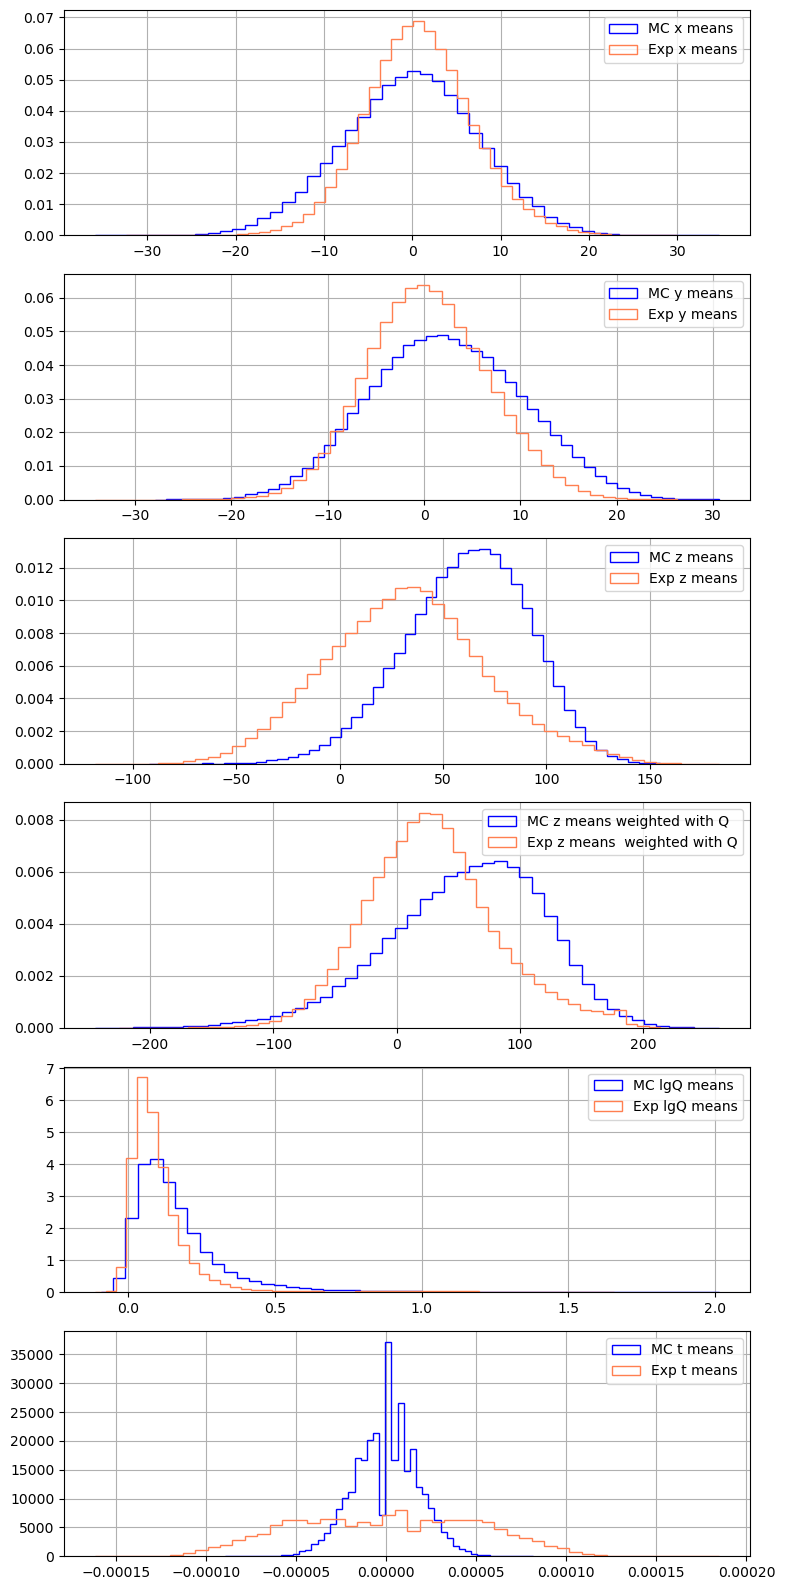

In [23]:
kwargs = dict(histtype='step', density=True)

fig, axs = plt.subplots(nrows=6, figsize=(8,16))
i = 0
#mc_mask = (~mc_labels)&(mc_signal_hit_nums>=8)&(mc_signal_string_nums>=2)

axs[i].hist(mc_x_means[mc_mask], bins=50, **kwargs, label='MC x means', ls='-', color='b')
axs[i].hist(exp_x_means, bins=50, **kwargs, label='Exp x means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

axs[i].hist(mc_y_means[mc_mask], bins=50, **kwargs, label='MC y means', ls='-', color='b')
axs[i].hist(exp_y_means, bins=50, **kwargs, label='Exp y means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

axs[i].hist(mc_z_means[mc_mask], bins=50, **kwargs, label='MC z means', ls='-', color='b')
axs[i].hist(exp_z_means, bins=50, **kwargs, label='Exp z means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

axs[i].hist(mc_z_weight_q[mc_mask], bins=50, **kwargs, label='MC z means weighted with Q', ls='-', color='b')
axs[i].hist(exp_z_weight_q, bins=50, **kwargs, label='Exp z means  weighted with Q', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1


axs[i].hist(np.log10(mc_q_means[mc_mask]), bins=50, **kwargs, label='MC lgQ means', ls='-', color='b')
axs[i].hist(np.log10(exp_q_means), bins=50, **kwargs, label='Exp lgQ means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

axs[i].hist(mc_t_means[mc_mask], bins=50, **kwargs, label='MC t means', ls='-', color='b')
axs[i].hist(exp_t_means, bins=50, **kwargs, label='Exp t means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

plt.tight_layout()
plt.show()

In [ ]:
# zs = []
# zsh8s2 = []
# for i, event in enumerate(tqdm(mc_raw_data, desc='MC stats collecting')):
#     z_coords = event[:,4]*z_std+z_mean
#     zs.append(z_coords)
#     if mc_signal_hit_nums[i]>=8 and mc_signal_string_nums[i]>=2:
#         zsh8s2.append(z_coords)
# zs = np.concat(zs)
# zsh8s2 = np.concat(zsh8s2)

MC stats collecting: 100%|██████████| 1000000/1000000 [00:05<00:00, 197353.63it/s]


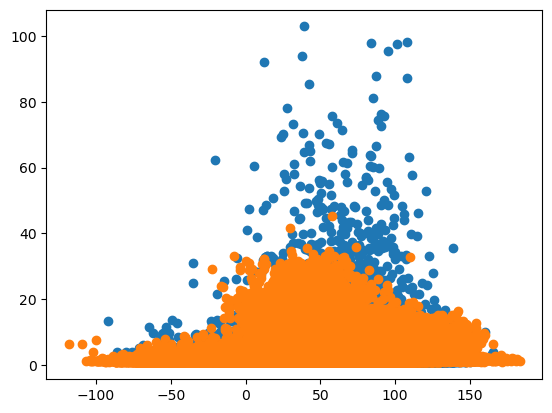

In [22]:
plt.scatter(mc_z_means[~mc_labels], mc_q_means[~mc_labels])
plt.scatter(exp_z_means, exp_q_means)

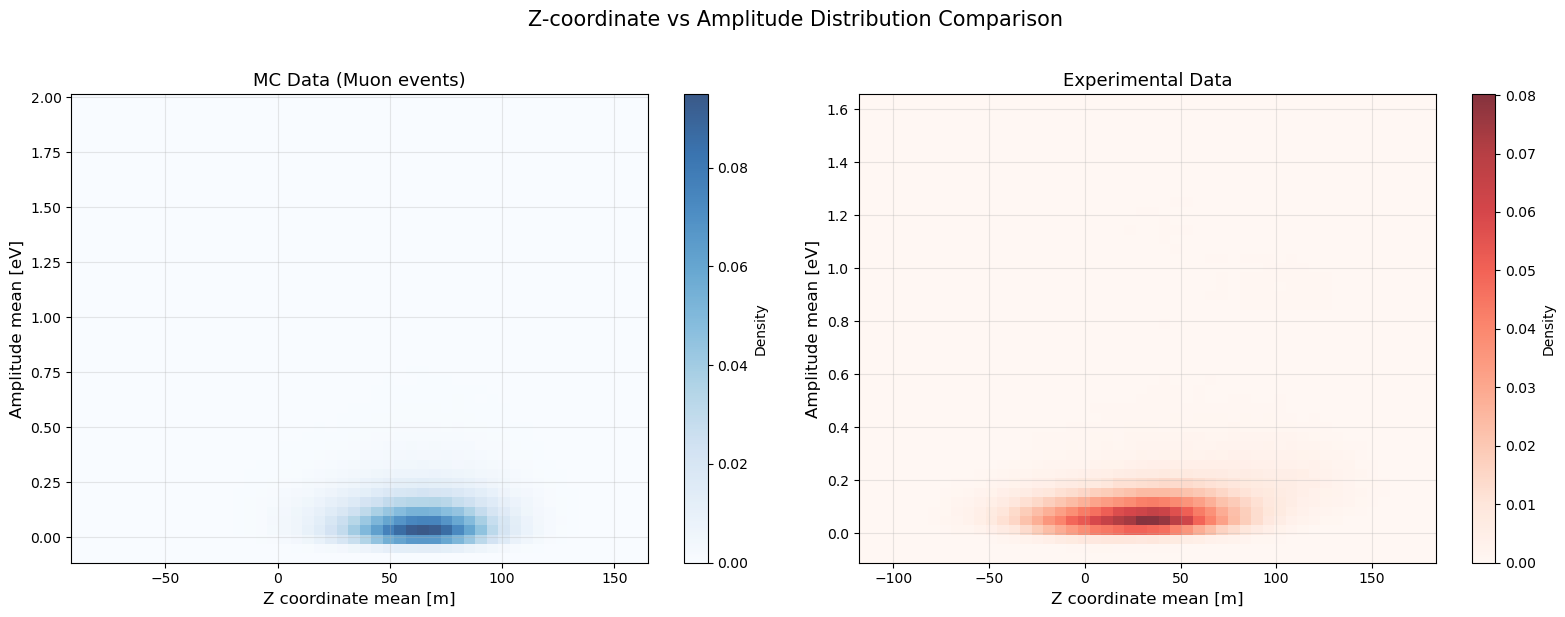

In [ ]:
plt.figure(figsize=(10, 8))

expq2plot = np.log10(exp_q_means)
mcq2plot = np.log10(mc_q_means[~mc_labels])

# # Create scatter plots with nice styling
# plt.scatter(mc_z_means[~mc_labels], mc_q_means[~mc_labels],
#             c='steelblue', alpha=0.6, s=8, label='MC (Muon events)', edgecolors='none')
# plt.scatter(exp_z_means, exp_q_means,
#             c='coral', alpha=0.7, s=8, label='EXP data', edgecolors='none')

# # Add styling
# plt.xlabel('Z coordinate mean [m]', fontsize=12)
# plt.ylabel('Amplitude mean [eV]', fontsize=12)
# plt.title('Z-coordinate vs Amplitude comparison: MC vs Experimental data', fontsize=14,
# pad=20)
# plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
# plt.grid(True, alpha=0.3, linestyle='--')

# # Set axis limits to focus on main data distribution
# plt.xlim(np.percentile(np.concatenate([mc_z_means[~mc_labels], exp_z_means]), [1, 99]))
# plt.ylim(np.percentile(np.concatenate([mc_q_means[~mc_labels], exp_q_means]), [1, 99]))

# # Add minor ticks for better readability
# plt.minorticks_on()
# plt.tick_params(which='major', length=6, width=1.2)
# plt.tick_params(which='minor', length=3, width=0.8)

# # Adjust layout and display
# plt.tight_layout()
# plt.show()`

#  For an even prettier version with density information:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Scatter with density coloring
from matplotlib.colors import LogNorm
import scipy.stats as stats

# Calculate 2D histogram for density coloring
expq2plot = np.log10(exp_q_means)
mcq2plot = np.log10(mc_q_means[~mc_labels])
mc_data = np.column_stack([mc_z_means[~mc_labels], mcq2plot])
exp_data = np.column_stack([exp_z_means, expq2plot])

# MC density plot
h1 = ax1.hist2d(mc_z_means[~mc_labels], mcq2plot,
                bins=50, density=True, cmap='Blues', alpha=0.8)
ax1.set_xlabel('Z coordinate mean [m]', fontsize=12)
ax1.set_ylabel('Amplitude mean [eV]', fontsize=12)
ax1.set_title('MC Data (Muon events)', fontsize=13)
ax1.grid(True, alpha=0.3)
plt.colorbar(h1[3], ax=ax1, label='Density')

# EXP density plot  
h2 = ax2.hist2d(exp_z_means, expq2plot,
                bins=50, density=True, cmap='Reds', alpha=0.8)
ax2.set_xlabel('Z coordinate mean [m]', fontsize=12)
ax2.set_ylabel('Amplitude mean [eV]', fontsize=12)
ax2.set_title('Experimental Data', fontsize=13)
ax2.grid(True, alpha=0.3)
plt.colorbar(h2[3], ax=ax2, label='Density')

plt.suptitle('Z-coordinate vs Amplitude Distribution Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Or for a contour-style comparison:

# fig, ax = plt.subplots(figsize=(10, 8))

# # Create contour plots for both datasets
# from scipy import stats

# # Calculate 2D kernel density estimates
# mc_x, mc_y = mc_z_means[~mc_labels], mc_q_means[~mc_labels]
# exp_x, exp_y = exp_z_means, exp_q_means

# # Create coordinate grids
# x_min, x_max = np.percentile(np.concatenate([mc_x, exp_x]), [1, 99])
# y_min, y_max = np.percentile(np.concatenate([mc_y, exp_y]), [1, 99])
# xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
# positions = np.vstack([xx.ravel(), yy.ravel()])

# # MC KDE
# mc_kernel = stats.gaussian_kde(np.vstack([mc_x, mc_y]))
# mc_density = np.reshape(mc_kernel(positions).T, xx.shape)

# # EXP KDE  
# exp_kernel = stats.gaussian_kde(np.vstack([exp_x, exp_y]))
# exp_density = np.reshape(exp_kernel(positions).T, xx.shape)

# # Plot contours
# contours_mc = ax.contour(xx, yy, mc_density, levels=6, colors='steelblue', alpha=0.8,
# linewidths=2)
# contours_exp = ax.contour(xx, yy, exp_density, levels=6, colors='coral', alpha=0.8,
# linewidths=2)

# # Add filled contours for better visualization
# ax.contourf(xx, yy, mc_density, levels=10, cmap='Blues', alpha=0.3)
# ax.contourf(xx, yy, exp_density, levels=10, cmap='Reds', alpha=0.3)

# # Styling
# ax.set_xlabel('Z coordinate mean [m]', fontsize=12)
# ax.set_ylabel('Amplitude mean [eV]', fontsize=12)
# ax.set_title('Z-coordinate vs Amplitude: Density Contours (MC vs EXP)', fontsize=14)
# ax.grid(True, alpha=0.3)

# # Custom legend
# from matplotlib.lines import Line2D
# legend_elements = [Line2D([0], [0], color='steelblue', lw=2, label='MC (Muon events)'),
#                     Line2D([0], [0], color='coral', lw=2, label='EXP data')]
# ax.legend(handles=legend_elements, fontsize=11)

# plt.tight_layout()
# plt.show()

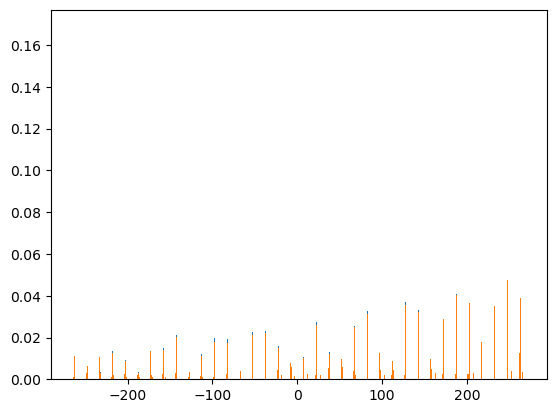

In [ ]:
# plt.hist(zsh8s2, bins=len(np.unique(zsh8s2)), density=True)
# plt.hist(zs, bins=len(np.unique(zs)), density=True)
# plt.show()

In [ ]:
kwargs = dict(histtype='step', density=True)

fig, axs = plt.subplots(nrows=6, figsize=(8,16))
i = 0

axs[i].hist(mc_z_means[~mc_labels], bins=50, **kwargs, label='MC z means', ls='-', color='b')
axs[i].hist(exp_z_means, bins=50, **kwargs, label='Exp z means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

axs[i].hist(mc_z_weight_q[~mc_labels], bins=50, **kwargs, label='MC z means weighted with Q', ls='-', color='b')
axs[i].hist(exp_z_weight_q, bins=50, **kwargs, label='Exp z means  weighted with Q', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1


axs[i].hist(np.log10(mc_q_means[~mc_labels]), bins=50, **kwargs, label='MC lgQ means', ls='-', color='b')
axs[i].hist(np.log10(exp_q_means), bins=50, **kwargs, label='Exp lgQ means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

axs[i].hist(mc_t_means[~mc_labels], bins=50, **kwargs, label='MC t means', ls='-', color='b')
axs[i].hist(exp_t_means, bins=50, **kwargs, label='Exp t means', ls='-', color='coral')
axs[i].grid()
axs[i].legend()
i+=1

plt.tight_layout()
plt.show()